# Time-Series & 3-Year Electoral Projections
**Goal:** train on past elections, validate on the most recent one, then project
abstention and dominant nuance forward to Y+1, Y+2, Y+3.

**Strategy:**
1. Build a per-commune time series of abstention rates across all available elections
2. Train a model on elections T-n … T-1, test on election T (temporal validation)
3. Extrapolate trends to T+1, T+2, T+3 using both a linear trend and the ML model
4. Flag communes whose trajectory is worsening (rising abstention / shifting nuance)


In [13]:
from pathlib import Path
import os
import warnings
warnings.filterwarnings("ignore")

import duckdb
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import numpy as np
import pandas as pd
import seaborn as sns

from sklearn.ensemble import GradientBoostingRegressor, RandomForestClassifier
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.model_selection import cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import LabelEncoder, StandardScaler

plt.style.use("seaborn-v0_8-whitegrid")
sns.set_theme(style="whitegrid")

ROOT_DIR = Path.cwd().resolve()
while not (ROOT_DIR / "data").exists() and ROOT_DIR != ROOT_DIR.parent:
    ROOT_DIR = ROOT_DIR.parent

SECURITY_DIR = ROOT_DIR / "data" / "gold" / "security"
ELECTION_DIR = ROOT_DIR / "data" / "gold" / "election"
FILOSOFI_DIR = ROOT_DIR / "data" / "gold" / "filosofi"
OUTPUT_DIR   = ROOT_DIR / "src" / "ml" / "timeseries" / "outputs"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

DB_PATH = ROOT_DIR / "data" / "electio.duckdb"

print("ROOT_DIR =", ROOT_DIR)
print("DB_PATH =", DB_PATH)

ROOT_DIR = /Users/zainfrayha/Desktop/electio-analytics-poc
DB_PATH = /Users/zainfrayha/Desktop/electio-analytics-poc/data/electio.duckdb


In [14]:
# ── Connect to DuckDB and load all tables ───────────────────────────────────
con = duckdb.connect(str(DB_PATH))

# Load CSV data into DuckDB if tables don't exist yet
tables_to_load = {
    # Security
    "fact_securite": SECURITY_DIR / "fact_securite.csv",
    "dim_indicateur_securite": SECURITY_DIR / "dim_indicateur_securite.csv",
    # Election
    "dim_commune": ELECTION_DIR / "dim_commune.csv",
    "dim_election": ELECTION_DIR / "dim_election.csv",
    "dim_nuance": ELECTION_DIR / "dim_nuance.csv",
    "fact_participation": ELECTION_DIR / "fact_participation.csv",
    "fact_resultats_candidat": ELECTION_DIR / "fact_resultats_candidat.csv",
    # Filosofi
    "fact_menages": FILOSOFI_DIR / "fact_menages.csv",
    "fact_pauvrete": FILOSOFI_DIR / "fact_pauvrete.csv",
    "fact_revenus": FILOSOFI_DIR / "fact_revenus.csv",
    "fact_deciles": FILOSOFI_DIR / "fact_deciles.csv",
}

for table_name, csv_path in tables_to_load.items():
    con.execute(f"""
        CREATE OR REPLACE TABLE {table_name} AS
        SELECT * FROM read_csv_auto('{csv_path}', sep=';')
    """)

# ── Query tables from DuckDB ─────────────────────────────────────────────────
fact_sec      = con.execute("SELECT * FROM fact_securite").df()
dim_indic     = con.execute("SELECT * FROM dim_indicateur_securite").df()
dim_commune   = con.execute("SELECT * FROM dim_commune").df()
dim_election  = con.execute("SELECT * FROM dim_election").df()
dim_nuance    = con.execute("SELECT * FROM dim_nuance").df()
fact_particip = con.execute("SELECT * FROM fact_participation").df()
fact_result   = con.execute("SELECT * FROM fact_resultats_candidat").df()
fact_menages  = con.execute("SELECT * FROM fact_menages").df()
fact_pauvrete = con.execute("SELECT * FROM fact_pauvrete").df()
fact_revenus  = con.execute("SELECT * FROM fact_revenus").df()
fact_deciles  = con.execute("SELECT * FROM fact_deciles").df()

con.close()

def norm_id(s):
    return s.astype(str).str.replace(r"\.0$","",regex=True).str.strip().str.zfill(5)

for df in [fact_sec, dim_commune, fact_particip, fact_result,
           fact_menages, fact_pauvrete, fact_revenus, fact_deciles]:
    df["id_commune"] = norm_id(df["id_commune"])

fact_sec["annee"]           = pd.to_numeric(fact_sec["annee"],           errors="coerce")
fact_sec["taux_pour_mille"] = pd.to_numeric(fact_sec["taux_pour_mille"], errors="coerce")
for df in [fact_menages, fact_pauvrete, fact_revenus, fact_deciles]:
    df["id_year"] = pd.to_numeric(df["id_year"], errors="coerce")

dim_commune_u = dim_commune[["id_commune","libelle_commune"]].drop_duplicates("id_commune")

print("✓ Loaded all tables from DuckDB")
print("Elections available:")
display(dim_election.sort_values(["annee_election","tour"]))

✓ Loaded all tables from DuckDB
Elections available:


,id_election,annee_election,tour
0,2012_T1,2012,1
1,2012_T2,2012,2
2,2017_T1,2017,1
3,2017_T2,2017,2
4,2022_T1,2022,1
5,2022_T2,2022,2


## Step 1 — Build the abstention time series across all elections

In [15]:
# Merge election metadata onto participation
fact_particip["pct_abs_ins"] = pd.to_numeric(fact_particip["pct_abs_ins"], errors="coerce")

ts = (
    fact_particip[["id_commune","id_election","pct_abs_ins"]]
    .merge(dim_election[["id_election","annee_election","tour"]], on="id_election", how="left")
    .merge(dim_commune_u, on="id_commune", how="left")
    .dropna(subset=["pct_abs_ins","annee_election"])
)

# Use tour 1 only for consistency — tour 2 has different dynamics
ts_t1 = ts[ts["tour"] == 1].copy()

print(f"Tour 1 participation rows: {len(ts_t1)}")
print(f"Elections (tour 1): {sorted(ts_t1['annee_election'].unique().astype(int).tolist())}")
print(f"Communes covered:   {ts_t1['id_commune'].nunique()}")

# Pivot to wide: rows=commune, cols=election year
ts_wide = ts_t1.pivot_table(
    index="id_commune", columns="annee_election",
    values="pct_abs_ins", aggfunc="mean"
)
ts_wide.columns = [int(c) for c in ts_wide.columns]

# Keep only communes present in ALL elections (clean time series)
ts_complete = ts_wide.dropna()
print(f"\nCommunes with complete data across all elections: {len(ts_complete)}")
print(f"Election years: {sorted(ts_wide.columns.tolist())}")

display(ts_complete.head(10).round(2))


Tour 1 participation rows: 840
Elections (tour 1): [2012, 2017, 2022]
Communes covered:   293

Communes with complete data across all elections: 267
Election years: [2012, 2017, 2022]


,2012,2017,2022
id_commune,,,
69001,10.00,11.20,18.99
69002,18.75,20.98,26.73
69003,17.18,19.04,22.46
69004,11.75,18.02,15.53
69005,12.60,15.00,14.74
69006,19.76,20.66,22.87
69007,14.03,15.55,18.94
69008,9.68,11.80,14.37
69009,14.11,18.99,20.96


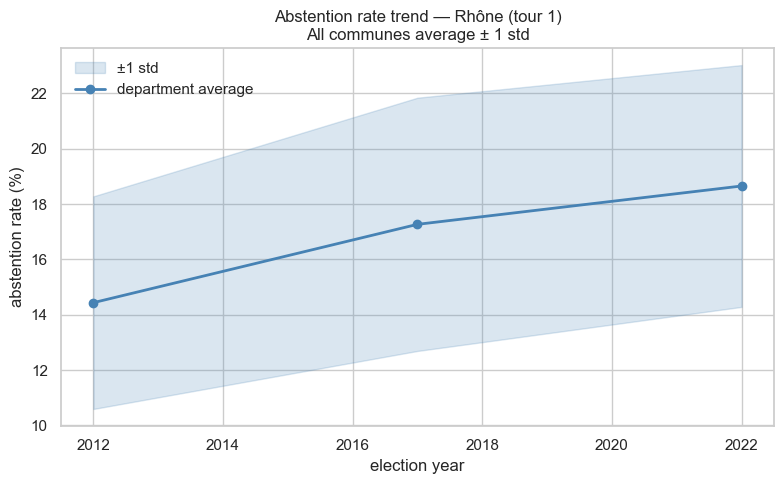

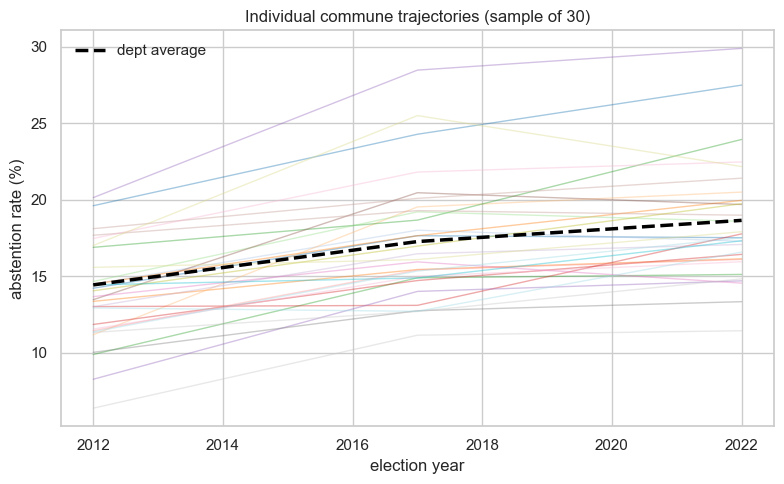


Communes with RISING abstention (2012→2022): 246
Communes with FALLING abstention (2012→2022): 21


In [16]:
years   = sorted(ts_complete.columns.tolist())
n_years = len(years)

# Department-wide average trend
dept_avg = ts_complete.mean(axis=0)

# Chart 1: mean trend with confidence band
std = ts_complete.std(axis=0)
fig, ax = plt.subplots(figsize=(8, 5))
ax.fill_between(years, dept_avg - std, dept_avg + std,
                alpha=0.2, color="steelblue", label="±1 std")
ax.plot(years, dept_avg, marker="o", color="steelblue",
        linewidth=2, label="department average")
ax.set_title("Abstention rate trend — Rhône (tour 1)\nAll communes average ± 1 std")
ax.set_xlabel("election year")
ax.set_ylabel("abstention rate (%)")
ax.legend()
plt.tight_layout()
plt.show()

# Chart 2: individual commune trends (sample of 30)
sample = ts_complete.sample(min(30, len(ts_complete)), random_state=42)
colors = cm.tab20(np.linspace(0, 1, len(sample)))
fig, ax = plt.subplots(figsize=(8, 5))
for (idx, row), color in zip(sample.iterrows(), colors):
    ax.plot(years, row.values, alpha=0.4, color=color, linewidth=1)
ax.plot(years, dept_avg, color="black", linewidth=2.5,
        linestyle="--", label="dept average")
ax.set_title("Individual commune trajectories (sample of 30)")
ax.set_xlabel("election year")
ax.set_ylabel("abstention rate (%)")
ax.legend()
plt.tight_layout()
plt.show()

# Rising vs falling communes
first_year, last_year = min(years), max(years)
ts_complete["trend_direction"] = np.where(
    ts_complete[last_year] > ts_complete[first_year], "rising", "falling"
)
print(f"\nCommunes with RISING abstention ({first_year}→{last_year}):",
      (ts_complete["trend_direction"]=="rising").sum())
print(f"Communes with FALLING abstention ({first_year}→{last_year}):",
      (ts_complete["trend_direction"]=="falling").sum())


## Step 2 — Linear trend per commune + 3-year projection

In [17]:
years_arr = np.array(years).reshape(-1, 1)

trend_results = []

for commune_id, row in ts_complete.iterrows():
    y = row[years].values.astype(float)
    lr = LinearRegression()
    lr.fit(years_arr, y)

    slope     = lr.coef_[0]
    intercept = lr.intercept_
    r2        = lr.score(years_arr, y)

    last_year_val = int(max(years))
    proj = {
        f"proj_{last_year_val+1}": lr.predict([[last_year_val + 1]])[0],
        f"proj_{last_year_val+2}": lr.predict([[last_year_val + 2]])[0],
        f"proj_{last_year_val+3}": lr.predict([[last_year_val + 3]])[0],
    }

    trend_results.append({
        "id_commune": commune_id,
        "slope_per_year": round(slope, 4),
        "r2_linear_fit": round(r2, 3),
        "abstention_first_year": round(y[0], 2),
        "abstention_last_year": round(y[-1], 2),
        "total_change": round(y[-1] - y[0], 2),
        **{k: round(v, 2) for k, v in proj.items()}
    })

trend_df = (
    pd.DataFrame(trend_results)
    .merge(dim_commune_u, on="id_commune", how="left")
)

last_yr = int(max(years))
proj_cols = [f"proj_{last_yr+1}", f"proj_{last_yr+2}", f"proj_{last_yr+3}"]

# Clip projections to [0, 100] — abstention can't exceed these bounds
for c in proj_cols:
    trend_df[c] = trend_df[c].clip(0, 100)

print("=== Abstention trend summary:")
print(f"  Average slope: {trend_df['slope_per_year'].mean():.3f} pts/year")
print(f"  Communes with rising trend (slope > 0): {(trend_df['slope_per_year'] > 0).sum()}")
print(f"  Communes with falling trend (slope < 0): {(trend_df['slope_per_year'] < 0).sum()}")
print()
print("=== Top 10 communes with FASTEST RISING abstention:")
display(
    trend_df.sort_values("slope_per_year", ascending=False)
    .head(10)[["libelle_commune","slope_per_year","abstention_last_year",
               *proj_cols]].reset_index(drop=True)
)
print()
print("=== Top 10 communes with FASTEST FALLING abstention:")
display(
    trend_df.sort_values("slope_per_year", ascending=True)
    .head(10)[["libelle_commune","slope_per_year","abstention_last_year",
               *proj_cols]].reset_index(drop=True)
)


=== Abstention trend summary:
  Average slope: 0.422 pts/year
  Communes with rising trend (slope > 0): 246
  Communes with falling trend (slope < 0): 21

=== Top 10 communes with FASTEST RISING abstention:


,libelle_commune,slope_per_year,abstention_last_year,proj_2023,proj_2024,proj_2025
0,Courzieu,1.271,24.11,24.47,25.74,27.01
1,Taponas,1.191,22.71,23.99,25.18,26.37
2,Saint-Fons,1.127,38.78,41.49,42.62,43.74
3,Feyzin,1.054,28.72,30.49,31.54,32.60
4,Moiré,1.027,17.10,17.14,18.16,19.19
5,Vaulx-en-Velin,1.019,40.45,43.58,44.60,45.62
6,Le Breuil,1.003,20.16,20.76,21.77,22.77
7,Saint-Clément-sous-Valsonne,0.991,20.90,22.33,23.32,24.31
8,Saint-Priest,0.975,29.89,32.02,32.99,33.97
9,Salles-Arbuissonnas-en-Beaujolais,0.948,17.35,19.32,20.27,21.21



=== Top 10 communes with FASTEST FALLING abstention:


,libelle_commune,slope_per_year,abstention_last_year,proj_2023,proj_2024,proj_2025
0,Montmelas-Saint-Sorlin,-0.341,12.01,11.26,10.92,10.58
1,Ville-sur-Jarnioux,-0.302,12.52,12.56,12.26,11.95
2,Meaux-la-Montagne,-0.252,13.61,15.90,15.65,15.40
3,Saint-Genis-Laval,-0.236,19.43,19.63,19.39,19.16
4,Lyon,-0.228,18.05,17.97,17.74,17.52
5,Saint-André-la-Côte,-0.210,14.81,13.68,13.47,13.26
6,Saint-Bonnet-le-Troncy,-0.183,17.24,17.59,17.41,17.23
7,Villié-Morgon,-0.136,19.65,19.24,19.11,18.97
8,Jullié,-0.129,15.79,15.11,14.98,14.85
9,Chambost-Longessaigne,-0.125,17.15,16.86,16.74,16.61


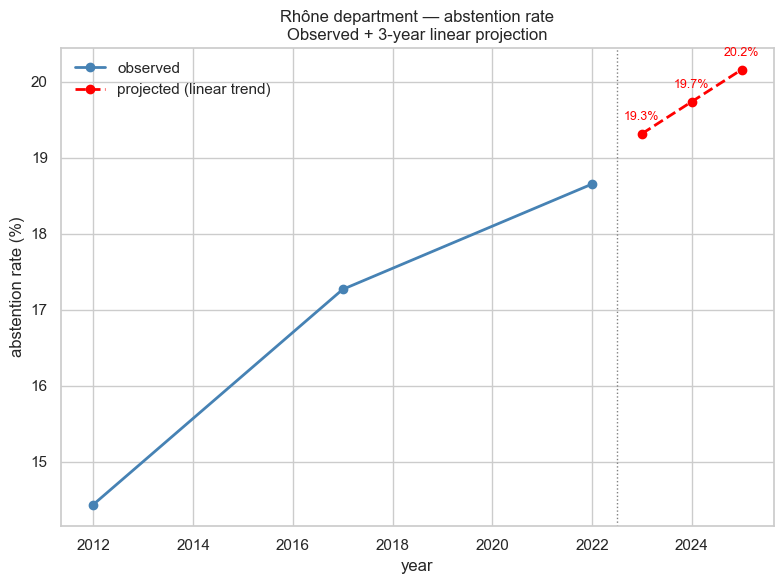

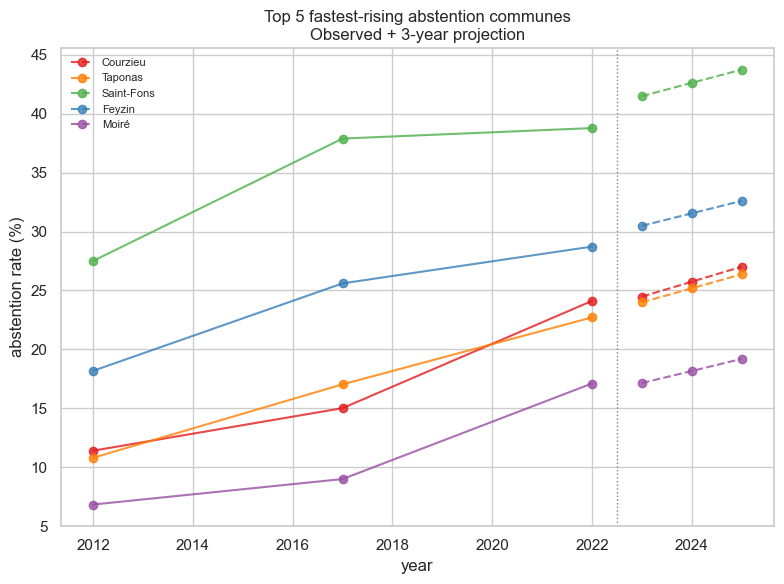

In [18]:
last_yr     = int(max(years))
future_yrs  = [last_yr + 1, last_yr + 2, last_yr + 3]
all_yrs     = years + future_yrs

# Department average projection
dept_lr = LinearRegression()
dept_lr.fit(np.array(years).reshape(-1,1), dept_avg.values)
dept_proj = dept_lr.predict(np.array(future_yrs).reshape(-1,1))

# Chart 1: department average + projection
fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(years, dept_avg.values, marker="o", color="steelblue",
        linewidth=2, label="observed")
ax.plot(future_yrs, dept_proj, marker="o", color="red",
        linewidth=2, linestyle="--", label="projected (linear trend)")
ax.axvline(last_yr + 0.5, color="gray", linestyle=":", linewidth=1)
ax.set_title("Rhône department — abstention rate\nObserved + 3-year linear projection")
ax.set_xlabel("year")
ax.set_ylabel("abstention rate (%)")
ax.legend()

for yr, proj in zip(future_yrs, dept_proj):
    ax.annotate(f"{proj:.1f}%",
                (yr, proj),
                textcoords="offset points", xytext=(0, 10),
                ha="center", fontsize=9, color="red")

plt.tight_layout()
plt.show()

# Chart 2: top 5 fastest-rising communes
top5_rising = trend_df.sort_values("slope_per_year", ascending=False).head(5)
colors5 = ["#e41a1c","#ff7f00","#4daf4a","#377eb8","#984ea3"]
fig, ax = plt.subplots(figsize=(8, 6))

for (_, row), color in zip(top5_rising.iterrows(), colors5):
    obs_vals  = ts_complete.loc[row["id_commune"], years].values
    proj_vals = [row[c] for c in proj_cols]
    ax.plot(years, obs_vals, marker="o", color=color,
            linewidth=1.5, alpha=0.8)
    ax.plot(future_yrs, proj_vals, marker="o", color=color,
            linewidth=1.5, linestyle="--", alpha=0.8,
            label=row["libelle_commune"])

ax.axvline(last_yr + 0.5, color="gray", linestyle=":", linewidth=1)
ax.set_title("Top 5 fastest-rising abstention communes\nObserved + 3-year projection")
ax.set_xlabel("year")
ax.set_ylabel("abstention rate (%)")
ax.legend(fontsize=8)

plt.tight_layout()
plt.show()


## Step 3 — ML model with temporal validation

In [19]:
# ── Rebuild feature matrix ────────────────────────────────────────────────────
latest_sec_year = int(fact_sec["annee"].max())
indicator_map   = dim_indic.set_index("id_indicateur_securite")["indicateur"].to_dict()

sec = fact_sec[
    (fact_sec["annee"] == latest_sec_year) &
    (fact_sec["est_diffuse"].astype(str).str.strip().str.lower().isin({"true","1","diff"}))
].copy()
sec["indicateur"] = sec["id_indicateur_securite"].map(indicator_map)

X_sec = (
    sec.pivot_table(index="id_commune", columns="indicateur",
                    values="taux_pour_mille", aggfunc="mean")
    .apply(lambda c: c.fillna(c.median()))
)
X_sec = X_sec.drop(columns=[c for c in
    ["Usage de stupéfiants (AFD)", "Vols avec armes"] if c in X_sec.columns])

filo = (
    fact_menages
    .merge(fact_pauvrete, on=["id_commune","id_year"], how="left")
    .merge(fact_revenus,  on=["id_commune","id_year"], how="left")
    .merge(fact_deciles,  on=["id_commune","id_year"], how="left")
)
latest_filo_year = int(filo["id_year"].dropna().max())
filo = filo[filo["id_year"] == latest_filo_year].copy()
filo_cols = [c for c in filo.columns if c not in ["id_commune","id_year"]]
for c in filo_cols:
    filo[c] = pd.to_numeric(filo[c], errors="coerce")
X_filo = filo.set_index("id_commune")[filo_cols].add_prefix("fil_")

DROP_FILO = [
    "fil_nb_menages_fiscaux","fil_nb_personnes_menages_fiscaux",
    "fil_pct_prestations_familiales","fil_pct_minima_sociaux",
    "fil_pct_prestations_logement","fil_pct_impots","fil_decile_1_revenu",
    "fil_taux_pauvrete_40_49ans","fil_taux_pauvrete_locataires",
    "fil_pct_revenus_salaires_chomage","fil_pct_revenus_non_salaries",
]
X_filo = X_filo.drop(columns=[c for c in DROP_FILO if c in X_filo.columns])
X_filo = X_filo.drop(columns=X_filo.columns[X_filo.isna().all()].tolist())
X_filo = X_filo.apply(lambda c: c.fillna(c.median()))

X_features = X_sec.join(X_filo, how="inner")
X_features  = X_features.apply(lambda c: c.fillna(c.median()))
X_features  = X_features.loc[:, X_features.nunique() > 1]

feature_cols = X_features.columns.tolist()
print(f"Feature matrix: {X_features.shape}")


Feature matrix: (265, 28)


Train elections: [2012, 2017]
Test  election : 2022  ← held out, never seen during training

Training samples: 530  (across 2 elections)
Test samples    : 265  (election 2022)

=== Temporal validation on election 2022 ===
  MAE : 2.13 percentage points
  R²  : 0.598

This R² is the honest score — trained on past elections, tested on a future one.
It tells you how well past socioeconomic patterns predict future electoral behaviour.


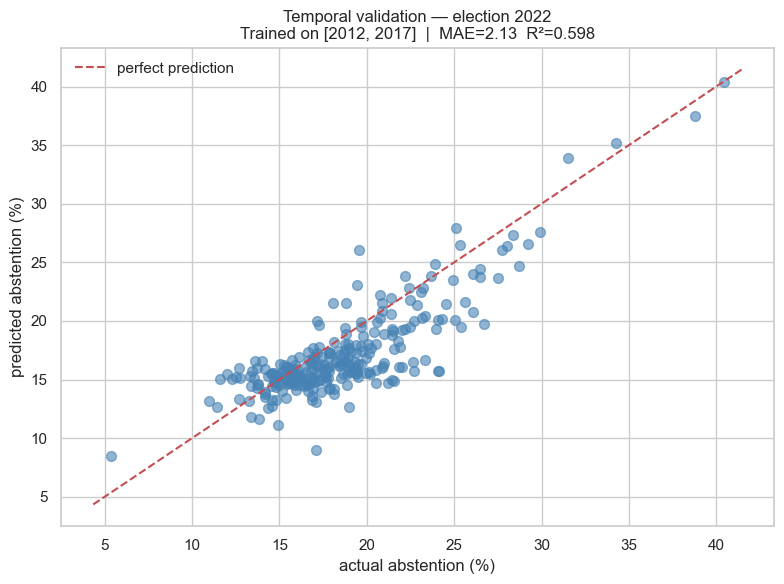

In [20]:
# ── Temporal validation ───────────────────────────────────────────────────────
# Train on all elections except the last one
# Test on the last election — this is the honest evaluation

elections_sorted = sorted(ts_t1["annee_election"].unique().astype(int).tolist())
train_elections  = elections_sorted[:-1]
test_election    = elections_sorted[-1]

print(f"Train elections: {train_elections}")
print(f"Test  election : {test_election}  ← held out, never seen during training")

def get_features_and_target(election_year, X_features, ts_t1, feature_cols):
    """Merge feature matrix with abstention for a given election year."""
    target = ts_t1[ts_t1["annee_election"] == election_year][["id_commune","pct_abs_ins"]]
    df = (
        X_features.reset_index()
        .merge(target, on="id_commune", how="inner")
        .dropna(subset=["pct_abs_ins"])
    )
    return df[feature_cols].values, df["pct_abs_ins"].values, df["id_commune"].values

# Stack all training elections
X_train_all, y_train_all = [], []
for yr in train_elections:
    X_yr, y_yr, _ = get_features_and_target(yr, X_features, ts_t1, feature_cols)
    # Add election year as a feature so model knows the temporal context
    year_col = np.full((len(X_yr), 1), yr)
    X_train_all.append(np.hstack([X_yr, year_col]))
    y_train_all.append(y_yr)

X_train = np.vstack(X_train_all)
y_train = np.concatenate(y_train_all)

# Test set: last election
X_te, y_te, commune_ids_te = get_features_and_target(
    test_election, X_features, ts_t1, feature_cols)
year_col_te = np.full((len(X_te), 1), test_election)
X_test = np.hstack([X_te, year_col_te])

print(f"\nTraining samples: {len(X_train)}  (across {len(train_elections)} elections)")
print(f"Test samples    : {len(X_test)}  (election {test_election})")

sc   = StandardScaler()
Xtr  = sc.fit_transform(X_train)
Xte  = sc.transform(X_test)

gbr = GradientBoostingRegressor(
    n_estimators=300, learning_rate=0.05,
    max_depth=3, subsample=0.8, random_state=42
)
gbr.fit(Xtr, y_train)
y_pred = gbr.predict(Xte)

mae = mean_absolute_error(y_te, y_pred)
r2  = r2_score(y_te, y_pred)

print(f"\n=== Temporal validation on election {test_election} ===")
print(f"  MAE : {mae:.2f} percentage points")
print(f"  R²  : {r2:.3f}")
print()
print("This R² is the honest score — trained on past elections, tested on a future one.")
print("It tells you how well past socioeconomic patterns predict future electoral behaviour.")

fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(y_te, y_pred, alpha=0.6, color="steelblue", s=50)
lims = [min(y_te.min(), y_pred.min())-1, max(y_te.max(), y_pred.max())+1]
ax.plot(lims, lims, "r--", linewidth=1.5, label="perfect prediction")
ax.set_title(f"Temporal validation — election {test_election}\n"
             f"Trained on {train_elections}  |  MAE={mae:.2f}  R²={r2:.3f}")
ax.set_xlabel("actual abstention (%)")
ax.set_ylabel("predicted abstention (%)")
ax.legend()
plt.tight_layout()
plt.show()


## Step 4 — 3-year forward projection using the ML model

In [21]:
# Project future years by feeding future year values into the trained model
# The socioeconomic features stay fixed (latest available)
# The election year feature increments — this encodes the time trend

last_yr    = int(max(years))
future_yrs = [last_yr + 1, last_yr + 2, last_yr + 3]

X_base = X_features.reset_index()
proj_records = []

for yr in future_yrs:
    X_yr      = X_base[feature_cols].values
    year_col  = np.full((len(X_yr), 1), yr)
    X_proj    = sc.transform(np.hstack([X_yr, year_col]))
    y_proj    = gbr.predict(X_proj).clip(0, 100)

    for i, commune_id in enumerate(X_base["id_commune"].values):
        proj_records.append({
            "id_commune": commune_id,
            "projection_year": yr,
            "predicted_abstention": round(y_proj[i], 2)
        })

proj_df = (
    pd.DataFrame(proj_records)
    .merge(dim_commune_u, on="id_commune", how="left")
)

# Pivot for readability
proj_wide = proj_df.pivot_table(
    index=["id_commune","libelle_commune"],
    columns="projection_year",
    values="predicted_abstention"
).reset_index()
proj_wide.columns = [str(c) for c in proj_wide.columns]
proj_wide = proj_wide.rename(columns={
    str(future_yrs[0]): f"abstention_{future_yrs[0]}",
    str(future_yrs[1]): f"abstention_{future_yrs[1]}",
    str(future_yrs[2]): f"abstention_{future_yrs[2]}",
})

# Add last observed value for comparison
last_obs = ts_t1[ts_t1["annee_election"] == last_yr][["id_commune","pct_abs_ins"]]
last_obs = last_obs.rename(columns={"pct_abs_ins": f"abstention_{last_yr}_observed"})
proj_wide = proj_wide.merge(last_obs, on="id_commune", how="left")

proj_wide[f"change_{last_yr}_to_{future_yrs[2]}"] = (
    proj_wide[f"abstention_{future_yrs[2]}"] -
    proj_wide[f"abstention_{last_yr}_observed"]
).round(2)

print("=== 3-year abstention projections (ML model):")
display(proj_wide.sort_values(
    f"abstention_{future_yrs[2]}", ascending=False).head(15).reset_index(drop=True))

print()
print(f"=== Communes projected to have HIGHEST abstention by {future_yrs[2]}:")
display(proj_wide.nlargest(10, f"abstention_{future_yrs[2]}")
        [["libelle_commune", f"abstention_{last_yr}_observed",
          f"abstention_{future_yrs[2]}", f"change_{last_yr}_to_{future_yrs[2]}"]
        ].reset_index(drop=True))

print()
print(f"=== Communes with LARGEST PROJECTED INCREASE by {future_yrs[2]}:")
display(proj_wide.nlargest(10, f"change_{last_yr}_to_{future_yrs[2]}")
        [["libelle_commune", f"abstention_{last_yr}_observed",
          f"abstention_{future_yrs[2]}", f"change_{last_yr}_to_{future_yrs[2]}"]
        ].reset_index(drop=True))


=== 3-year abstention projections (ML model):


,id_commune,libelle_commune,abstention_2023,abstention_2024,abstention_2025,abstention_2022_observed,change_2022_to_2025
0,69256,Vaulx-en-Velin,40.37,40.37,40.37,40.45,-0.08
1,69199,Saint-Fons,37.47,37.47,37.47,38.78,-1.31
2,69091,Givors,35.17,35.17,35.17,34.24,0.93
3,69259,Vénissieux,33.88,33.88,33.88,31.50,2.38
4,69096,Grigny,27.92,27.92,27.92,25.09,2.83
5,69290,Saint-Priest,27.61,27.61,27.61,29.89,-2.28
6,69264,Villefranche-sur-Saône,27.29,27.29,27.29,28.34,-1.05
7,69243,Tarare,26.59,26.59,26.59,29.24,-2.65
8,69286,Rillieux-la-Pape,26.52,26.52,26.52,25.34,1.18
9,69275,Décines-Charpieu,26.36,26.36,26.36,28.01,-1.65



=== Communes projected to have HIGHEST abstention by 2025:


,libelle_commune,abstention_2022_observed,abstention_2025,change_2022_to_2025
0,Vaulx-en-Velin,40.45,40.37,-0.08
1,Saint-Fons,38.78,37.47,-1.31
2,Givors,34.24,35.17,0.93
3,Vénissieux,31.50,33.88,2.38
4,Grigny,25.09,27.92,2.83
5,Saint-Priest,29.89,27.61,-2.28
6,Villefranche-sur-Saône,28.34,27.29,-1.05
7,Tarare,29.24,26.59,-2.65
8,Rillieux-la-Pape,25.34,26.52,1.18
9,Décines-Charpieu,28.01,26.36,-1.65



=== Communes with LARGEST PROJECTED INCREASE by 2025:


,libelle_commune,abstention_2022_observed,abstention_2025,change_2022_to_2025
0,Ecully,19.53,26.01,6.48
1,Saint-Genis-Laval,19.43,23.05,3.62
2,Lyon,18.05,21.55,3.50
3,Belmont-d'Azergues,11.58,15.02,3.44
4,Montmelas-Saint-Sorlin,12.01,15.45,3.44
5,Duerne,12.69,15.94,3.25
6,Saint-Cyr-le-Chatoux,5.34,8.51,3.17
7,Meaux-la-Montagne,13.61,16.54,2.93
8,Sérézin-du-Rhône,17.15,20.03,2.88
9,Grigny,25.09,27.92,2.83


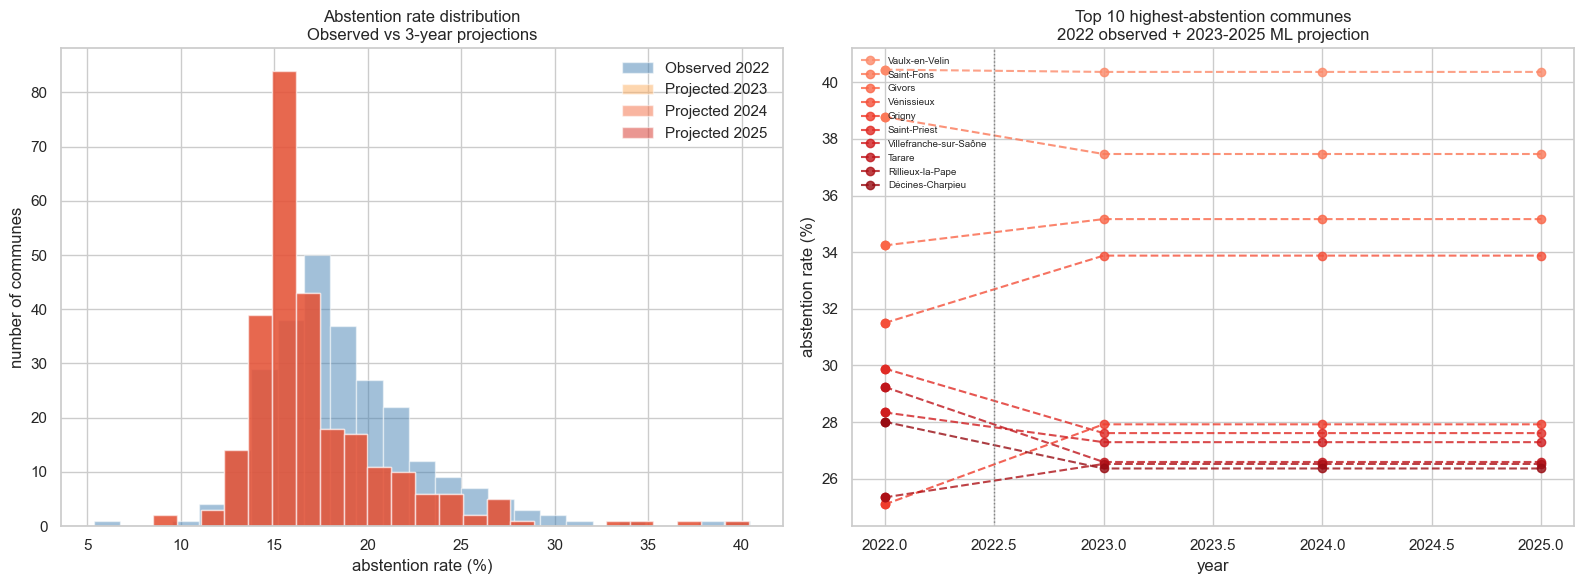

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Left: distribution shift across projection years
obs_col  = f"abstention_{last_yr}_observed"
proj_cols_plot = [f"abstention_{y}" for y in future_yrs]

for col, label, color in zip(
    [obs_col] + proj_cols_plot,
    [f"Observed {last_yr}"] + [f"Projected {y}" for y in future_yrs],
    ["steelblue", "#fdae61", "#f46d43", "#d73027"]
):
    vals = proj_wide[col].dropna()
    axes[0].hist(vals, bins=25, alpha=0.5, color=color, label=label, edgecolor="white")

axes[0].set_title("Abstention rate distribution\nObserved vs 3-year projections")
axes[0].set_xlabel("abstention rate (%)")
axes[0].set_ylabel("number of communes")
axes[0].legend()

# Right: top 10 most at-risk communes — trajectory
top10 = proj_wide.nlargest(10, f"abstention_{future_yrs[2]}")
colors10 = plt.cm.Reds(np.linspace(0.4, 0.9, len(top10)))

for (_, row), color in zip(top10.iterrows(), colors10):
    obs_vals  = [row[obs_col]] if not pd.isna(row[obs_col]) else [None]
    proj_vals = [row[f"abstention_{y}"] for y in future_yrs]
    all_vals  = obs_vals + proj_vals
    all_yrs_p = [last_yr] + future_yrs
    valid     = [(y, v) for y, v in zip(all_yrs_p, all_vals) if v is not None]
    if valid:
        ys, vs = zip(*valid)
        axes[1].plot(ys[:1], vs[:1], marker="o", color=color, linewidth=2)
        axes[1].plot(ys, vs, marker="o", color=color, linewidth=1.5,
                     linestyle="--", alpha=0.8, label=row["libelle_commune"])

axes[1].axvline(last_yr + 0.5, color="gray", linestyle=":", linewidth=1)
axes[1].set_title(f"Top 10 highest-abstention communes\n{last_yr} observed + {future_yrs[0]}-{future_yrs[2]} ML projection")
axes[1].set_xlabel("year")
axes[1].set_ylabel("abstention rate (%)")
axes[1].legend(fontsize=7, loc="upper left")

plt.tight_layout()
plt.show()


## Step 5 — Alert table for ElectioAnalytics

In [23]:
# Combine linear trend + ML projection into one strategic table
alert_df = (
    trend_df[["id_commune","libelle_commune","slope_per_year",
              "abstention_last_year", *[f"proj_{y}" for y in future_yrs]]]
    .rename(columns={f"proj_{y}": f"linear_proj_{y}" for y in future_yrs})
    .merge(
        proj_wide[["id_commune"] + [f"abstention_{y}" for y in future_yrs]]
        .rename(columns={f"abstention_{y}": f"ml_proj_{y}" for y in future_yrs}),
        on="id_commune", how="left"
    )
)

# Average the two projection methods for robustness
for y in future_yrs:
    lin = alert_df[f"linear_proj_{y}"]
    ml  = alert_df[f"ml_proj_{y}"]
    alert_df[f"consensus_proj_{y}"] = ((lin + ml) / 2).round(2)

# Risk flag: commune is "at risk" if consensus projection Y+3 > 50%
# OR if the increase from last observed to Y+3 > 5 points
last_obs_col = f"abstention_{last_yr}_observed"
alert_df = alert_df.merge(
    proj_wide[["id_commune", last_obs_col]], on="id_commune", how="left"
)
alert_df["risk_flag"] = (
    alert_df[f"consensus_proj_{future_yrs[2]}"] >= 40
)

print(f"=== Communes flagged as AT RISK of high abstention by {future_yrs[2]}:")
print(f"    ({alert_df['risk_flag'].sum()} communes flagged)")
print()

display(
    alert_df[alert_df["risk_flag"]]
    .sort_values(f"consensus_proj_{future_yrs[2]}", ascending=False)
    [[  "libelle_commune", last_obs_col,
        f"consensus_proj_{future_yrs[0]}",
        f"consensus_proj_{future_yrs[1]}",
        f"consensus_proj_{future_yrs[2]}",
        "slope_per_year"
    ]].reset_index(drop=True)
    .rename(columns={
        last_obs_col: f"observed_{last_yr}",
        f"consensus_proj_{future_yrs[0]}": f"proj_{future_yrs[0]}",
        f"consensus_proj_{future_yrs[1]}": f"proj_{future_yrs[1]}",
        f"consensus_proj_{future_yrs[2]}": f"proj_{future_yrs[2]}",
    })
)

# Save
alert_df.to_csv(OUTPUT_DIR / "abstention_projections_3yr.csv", index=False)
print(f"\nSaved: abstention_projections_3yr.csv")


=== Communes flagged as AT RISK of high abstention by 2025:
    (0 communes flagged)



,libelle_commune,observed_2022,proj_2023,proj_2024,proj_2025,slope_per_year



Saved: abstention_projections_3yr.csv


  2023: mean=18.2%  pessimistic=22.4%  optimistic=14.1%
  2024: mean=18.5%  pessimistic=22.7%  optimistic=14.3%
  2025: mean=18.7%  pessimistic=22.9%  optimistic=14.4%


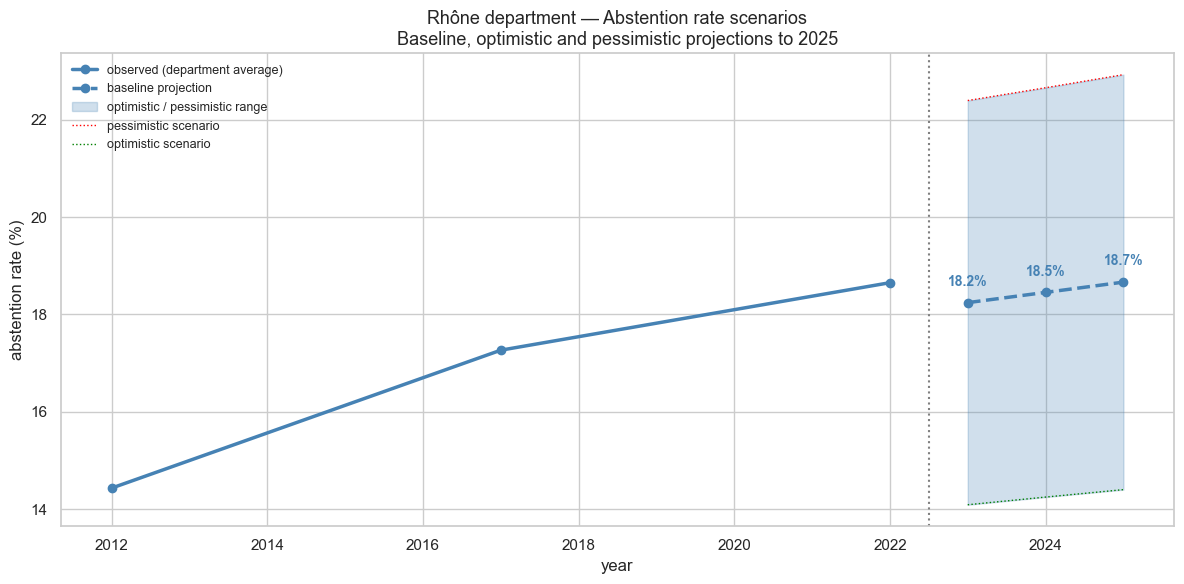


This is the key deliverable chart for ElectioAnalytics.
It shows where abstention is heading under three scenarios,
which directly feeds their 1-3 year strategic planning.


In [24]:
# Final summary: 3 scenarios for the department
# Pessimistic = mean + 1std of projections
# Baseline    = mean projection
# Optimistic  = mean - 1std of projections

for y in future_yrs:
    col = f"consensus_proj_{y}"
    print(f"  {y}: mean={alert_df[col].mean():.1f}%  "
          f"pessimistic={alert_df[col].mean()+alert_df[col].std():.1f}%  "
          f"optimistic={alert_df[col].mean()-alert_df[col].std():.1f}%")

dept_mean_obs = ts_complete[years].mean(axis=0).values
dept_mean_proj = [alert_df[f"consensus_proj_{y}"].mean() for y in future_yrs]
dept_pess_proj = [alert_df[f"consensus_proj_{y}"].mean() +
                  alert_df[f"consensus_proj_{y}"].std() for y in future_yrs]
dept_opti_proj = [alert_df[f"consensus_proj_{y}"].mean() -
                  alert_df[f"consensus_proj_{y}"].std() for y in future_yrs]

fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(years, dept_mean_obs, marker="o", color="steelblue",
        linewidth=2.5, label="observed (department average)")
ax.plot(future_yrs, dept_mean_proj, marker="o", color="steelblue",
        linewidth=2.5, linestyle="--", label="baseline projection")
ax.fill_between(future_yrs, dept_opti_proj, dept_pess_proj,
                alpha=0.25, color="steelblue", label="optimistic / pessimistic range")
ax.plot(future_yrs, dept_pess_proj, color="red", linewidth=1,
        linestyle=":", label="pessimistic scenario")
ax.plot(future_yrs, dept_opti_proj, color="green", linewidth=1,
        linestyle=":", label="optimistic scenario")

for y, v in zip(future_yrs, dept_mean_proj):
    ax.annotate(f"{v:.1f}%", (y, v),
                textcoords="offset points", xytext=(0, 12),
                ha="center", fontsize=10, color="steelblue", fontweight="bold")

ax.axvline(max(years) + 0.5, color="gray", linestyle=":", linewidth=1.5)
ax.set_title("Rhône department — Abstention rate scenarios\n"
             "Baseline, optimistic and pessimistic projections to "
             f"{future_yrs[-1]}", fontsize=13)
ax.set_xlabel("year")
ax.set_ylabel("abstention rate (%)")
ax.legend(loc="upper left", fontsize=9)
plt.tight_layout()
plt.show()

print()
print("This is the key deliverable chart for ElectioAnalytics.")
print("It shows where abstention is heading under three scenarios,")
print("which directly feeds their 1-3 year strategic planning.")
